### Preamble

In [19]:
try:
    import pgmuvi
except (ImportError, ModuleNotFoundError):
    %pip install -q git+https://github.com/ICSM/pgmuvi.git
    import pgmuvi

In [21]:
# Imports and seeds for reproducibility
import gpytorch
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood

seed = 0
import torch
torch.manual_seed(seed)

import numpy as np
np.random.seed(seed)

import random
random.seed(seed)

from pgmuvi.lightcurve import Lightcurve
from gpytorch.constraints import Interval
import pgmuvi.gps as gps
from pgmuvi import synthetic
from pgmuvi.preprocess import subsample_lightcurve

SEED = 0
TRAINING_ITER = 1000
DTYPE = torch.float64
DEVICE = torch.device("cpu")

### The `Lightcurve` object

##### The central object in `pgmuvi` is the `Lightcurve` class. It can store either a light curve defined for a single wavelength (a "1D light curve") or a set of light-curve observations defined over time and wavelength (a "2D light curve").

##### At the very least, a `Lightcurve` stores:

- `xdata` — the independent-variable data
  - for a 1D light curve: time
  - for a 2D light curve: a 2-column array, with time in the first column and wavelength in the second
- `ydata` — the flux values
- `yerr` — the flux uncertainties, if available
- `band` — an optional array of per-row string labels, mainly useful for manipulating 2D light curves

##### In addition to the core arrays, the class also supports a small amount of lightweight metadata:

- `name` — a human-readable name for the light curve
- `time_units` — passed at construction time so that the time axis can be converted internally to **days**

This is useful, but it is also important to be precise about what the class does **not** currently provide.

##### The current implementation is **not** a general metadata container.

For example, there is no dedicated built-in schema for storing and round-tripping arbitrary metadata such as:

- source name
- telescope/instrument
- photometric system
- physical flux units
- provenance information

So if you need richer metadata, you should currently manage that outside the `Lightcurve` object or extend the class explicitly.

##### A `Lightcurve` object can be instantiated either by providing `xdata`, `ydata`, and optionally `yerr` directly, or by reading a CSV file with `Lightcurve.from_csv()`.

### In this notebook, we will demonstrate some features available for `Lightcurve` objects to manipulate 1D and 2D light curve data.

### Data structure and invariants

Before using the `Lightcurve` object, it is essential to understand the assumptions it makes about the input data. Many downstream methods (especially period finding and GP fitting) will silently fail or produce misleading results if these assumptions are violated.

#### Core inputs

A `Lightcurve` is constructed from:

- `time` — observation times
- `flux` — measured flux values
- `flux_err` — uncertainties on flux
- `wavelength` — wavelength(s) corresponding to the observations
- `band` *(optional but recommended)* — string labels identifying each wavelength channel

---

#### Shape expectations

##### 1D lightcurve (single band)
- `time`: shape `(N,)`
- `flux`: shape `(N,)`
- `flux_err`: shape `(N,)`
- `wavelength`: scalar or `(N,)`
- `band`: single string or `(N,)` constant

##### 2D lightcurve (multi-band)
- `time`: shape `(N,)`
- `flux`: shape `(N, M)`
- `flux_err`: shape `(N, M)`
- `wavelength`: shape `(M,)`
- `band`: shape `(M,)` (array of strings)

Each column in `flux` corresponds to one band.

---

#### Critical invariants

The following must hold:

1. `len(time) == flux.shape[0] == flux_err.shape[0]`
2. `flux.shape == flux_err.shape`
3. Number of bands must match:
   - `flux.shape[1] == len(wavelength) == len(band)` (for 2D case)
4. No implicit reshaping is performed — mismatches should raise errors

---

#### Common pitfalls

- Mixing 1D and 2D inputs unintentionally
- Providing `band` labels as floats instead of strings
- Mismatched number of bands vs flux columns
- Silent broadcasting errors if shapes are inconsistent
- Unsorted time arrays (not always enforced!)

---

In the next cell, we explicitly test these constraints.

In [22]:
import numpy as np
from pgmuvi.lightcurve import Lightcurve

# ------------------------------------------------------------
# Valid 2-D example
#
# In this codebase, a multiband light curve is stored with:
#   xdata.shape == (N, 2)
# where:
#   xdata[:, 0] = time
#   xdata[:, 1] = wavelength
#
# ydata and yerr are 1-D arrays of length N
# band is optional, but if provided for 2-D data it must be a
# 1-D array of strings with exactly one label per observation row
# (so len(band) == N, not number of unique wavelengths).
# ------------------------------------------------------------

xdata = np.array([
    [0.0, 1.25],
    [1.0, 1.25],
    [2.0, 1.25],
    [0.5, 2.20],
    [1.5, 2.20],
    [2.5, 2.20],
], dtype=float)

ydata = np.array([10.0, 10.4, 10.2, 7.8, 8.1, 7.9], dtype=float)
yerr = np.array([0.2, 0.2, 0.2, 0.15, 0.15, 0.15], dtype=float)

band = np.array(["J", "J", "J", "K", "K", "K"])

lc = Lightcurve(
    xdata,
    ydata,
    yerr=yerr,
    band=band,
)

print("Valid Lightcurve created.")
print("xdata shape:", lc.xdata.shape)
print("ydata shape:", lc.ydata.shape)
print("ndim:", lc.ndim)
print("band:", lc.band)


# ------------------------------------------------------------
# Invalid example 1: band length mismatch
#
# For 2-D light curves, band must have one entry per row.
# ------------------------------------------------------------
try:
    bad_band = np.array(["J", "K"])  # incorrect length
    lc_bad_band = Lightcurve(
        xdata,
        ydata,
        yerr=yerr,
        band=bad_band,
    )
except Exception as e:
    print("\nExpected failure (band length mismatch):")
    print(type(e).__name__, e)


# ------------------------------------------------------------
# Invalid example 2: band is not 1-D
# ------------------------------------------------------------
try:
    bad_band_shape = np.array([["J"], ["J"], ["J"], ["K"], ["K"], ["K"]])
    lc_bad_band_shape = Lightcurve(
        xdata,
        ydata,
        yerr=yerr,
        band=bad_band_shape,
    )
except Exception as e:
    print("\nExpected failure (band must be 1-D):")
    print(type(e).__name__, e)


# ------------------------------------------------------------
# Invalid example 3: NaN in xdata
#
# The xdata setter explicitly rejects NaNs.
# ------------------------------------------------------------
try:
    xdata_nan = xdata.copy()
    xdata_nan[2, 0] = np.nan
    lc_nan = Lightcurve(
        xdata_nan,
        ydata,
        yerr=yerr,
        band=band,
    )
except Exception as e:
    print("\nExpected failure (NaN in xdata):")
    print(type(e).__name__, e)


# ------------------------------------------------------------
# Valid 1-D example
#
# For a 1-D light curve:
#   xdata is just time
#   ydata is flux
#   yerr is flux uncertainty
#
# band may be omitted, or may be a single shared label.
# ------------------------------------------------------------
time = np.array([0.0, 1.0, 2.0, 3.0], dtype=float)
flux = np.array([12.1, 12.4, 12.0, 12.3], dtype=float)
flux_err = np.array([0.1, 0.1, 0.1, 0.1], dtype=float)

lc_1d = Lightcurve(
    time,
    flux,
    yerr=flux_err,
    band=np.array(["V"]),
)

print("\nValid 1-D Lightcurve created.")
print("xdata shape:", lc_1d.xdata.shape)
print("ydata shape:", lc_1d.ydata.shape)
print("ndim:", lc_1d.ndim)
print("band:", lc_1d.band)

Valid Lightcurve created.
xdata shape: torch.Size([6, 2])
ydata shape: torch.Size([6])
ndim: 2
band: ['J' 'J' 'J' 'K' 'K' 'K']

Expected failure (band length mismatch):
ValueError Length of 'band' (2) does not match the expected number of rows (6).

Expected failure (band must be 1-D):
ValueError 'band' must be a 1-D array-like of strings (shape (n,)); got shape (6, 1).

Valid 1-D Lightcurve created.
xdata shape: torch.Size([4])
ydata shape: torch.Size([4])
ndim: 1
band: ['V']


/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1840: UserWarning: The function expects a torch.Tensor as input.Your data will be converted to a tensor.
  xdata = self._ensure_tensor(xdata)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1841: UserWarning: The function expects a torch.Tensor as input.Your data will be converted to a tensor.
  ydata = self._ensure_tensor(ydata)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1843: UserWarning: The function expects a torch.Tensor as input.Your data will be converted to a tensor.
  yerr = self._ensure_tensor(yerr)
/tmp/ipykernel_2728/3967147311.py:89: UserWarning: Dropped 1 row(s) containing non-finite (NaN or Inf) values.
  lc_nan = Lightcurve(
/tmp/ipykernel_2728/3967147311.py:89: UserWarning: Fewer than 10 elements remain after dropping 1 rows, take care interpreting results!
  lc_nan = Lightcurve(


In [23]:
# Minimal demonstration of lightweight metadata currently supported by Lightcurve

import numpy as np
from pgmuvi.lightcurve import Lightcurve

time_hours = np.array([0.0, 12.0, 24.0, 36.0], dtype=float)
flux = np.array([1.0, 1.1, 0.9, 1.05], dtype=float)
flux_err = np.array([0.05, 0.05, 0.05, 0.05], dtype=float)

lc_meta = Lightcurve(
    time_hours,
    flux,
    yerr=flux_err,
    name="Example light curve",
    time_units="hr",
    band=np.array(["V"]),
)

print("name:", lc_meta.name)
print("band:", lc_meta.band)
print("xdata (stored internally in days):")
print(lc_meta.xdata)

print("\nDoes the object expose a dedicated metadata container?")
print("meta attribute present ->", hasattr(lc_meta, "meta"))

name: Example light curve
band: ['V']
xdata (stored internally in days):
tensor([0.0000, 0.5000, 1.0000, 1.5000])

Does the object expose a dedicated metadata container?
meta attribute present -> False


### Missing and non-finite data

The current `Lightcurve` implementation does **not** expose a dedicated masking interface such as a boolean mask attribute or a `.mask()` method.

Instead, the behavior is:

1. **At direct construction time (`Lightcurve(...)`)**
   - if the main data arrays are 1D in the supported standard format, rows containing **NaN or Inf** in `xdata`, `ydata`, or `yerr` are dropped automatically
   - a warning is emitted if rows are dropped
   - if no valid rows remain, a `ValueError` is raised

2. **At CSV read time (`Lightcurve.from_csv(...)`)**
   - rows containing missing values in the relevant columns are dropped automatically before the object is constructed
   - empty strings in string-valued columns are also treated as missing
   - if all rows are dropped, a `ValueError` is raised

So the package currently follows a **drop-invalid-rows** strategy rather than a **mask-and-retain** strategy.

This is important because it means:

- the number of rows in the final `Lightcurve` may be smaller than the input data
- invalid rows are not preserved for later masking/unmasking
- if you want custom masking logic, you should apply it **before** constructing the `Lightcurve`

In [24]:
import numpy as np
import warnings
from pgmuvi.lightcurve import Lightcurve

# Example: direct Lightcurve construction drops rows with NaN/Inf
x_bad = np.array([
    [0.0, 0.8],
    [1.0, 0.8],
    [2.0, 0.8],
    [3.0, 0.8],
], dtype=float)

y_bad = np.array([1.0, np.nan, 1.2, np.inf], dtype=float)
yerr_bad = np.array([0.1, 0.1, 0.1, 0.1], dtype=float)
band_bad = np.array(["band 1", "band 1", "band 1", "band 1"])

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    try:
      lc_clean = Lightcurve(
          x_bad,
          y_bad,
          yerr=yerr_bad,
          band=band_bad,
      )
      print("Input number of rows:", len(y_bad))
      print("Rows retained in Lightcurve:", len(lc_clean.ydata))
      print("Retained xdata:")
      print(lc_clean.xdata)
    except Exception as e:
      print("Expected failure:")
      print(type(e).__name__, e)
if w:
    print("\nWarning emitted during construction:")
    print(str(w[0].message))



Input number of rows: 4
Rows retained in Lightcurve: 2
Retained xdata:
tensor([[0.0000, 0.8000],
        [2.0000, 0.8000]])

Warning emitted during construction:
The function expects a torch.Tensor as input.Your data will be converted to a tensor.


In [25]:
# Example: CSV reading also drops invalid rows automatically

csv_text = """time,wavelength,flux,flux_err,band
0.0,0.8,1.00,0.10,band 1
1.0,0.8,nan,0.10,band 1
2.0,0.8,1.20,0.10,band 1
3.0,0.8,1.30,0.10,
4.0,0.8,1.40,0.10,band 1
"""

with open("lightcurve_with_missing_rows.csv", "w") as f:
    f.write(csv_text)

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    lc_csv_clean = Lightcurve.from_csv("lightcurve_with_missing_rows.csv")

print("Rows retained after from_csv:", len(lc_csv_clean.ydata))
print("Retained xdata:")
print(lc_csv_clean.xdata)
print("Retained band labels:")
print(lc_csv_clean.band)

if w:
    print("\nWarning emitted during CSV read:")
    print(str(w[0].message))

Rows retained after from_csv: 4
Retained xdata:
tensor([0., 2., 3., 4.])
Retained band labels:
['band 1']

Warning emitted during CSV read:
Dropped 1 row(s) containing NaN values.


### Generating synthetic data

##### Synthetic data can of course be generated manually, but PGMUVI also has built-in methods to generate such data. We will demonstrate both these methods below.

The following generates a 1D light curve with data generated manually

In [26]:
""" Manual method: generate a perturbed sine curve with one period component"""

P = np.random.uniform(30, 300)  # 137. #Days!
print("True period: ", P, " days")
n_data = 400
jd_min = 2450000
n_periods = np.random.uniform(3, 10)
jd_max = jd_min + P * (n_periods)
print("Simulating for ", n_periods, " periods")

# generate data from a simple case - superimpose two sine curves and add noise
timestamps_1d = torch.Tensor(
    np.random.uniform(jd_min, jd_max, size=n_data)
)  # generate random x data here
fluxes_1d = torch.sin(timestamps_1d * (2 * np.pi / P))  # generate random y data here
fluxes_1d += 0.1 * torch.randn_like(fluxes_1d)
flux_err_1d = 0.1 * fluxes_1d.abs()

lc1d_manual = Lightcurve(timestamps_1d, fluxes_1d, yerr=flux_err_1d)

True period:  178.17964606037768  days
Simulating for  8.006325564606936  periods


We can use the `synthetic.py` script instead. The following generates a 2D light curve with a single period component

In [27]:
"""Generate a set of mono-periodic light curves using synthetic.py"""

n_per_band = (25, 40) # number of data points per light curve limited to this range

SINGLE_DATASET_CONFIG = dict(
    period=150,
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.8, 1.2, 2.2], # wavelengths in µm
    amplitude_law="extinction",
    seed=SEED,
)

lc2d_synth_1comp = synthetic.make_chromatic_sinusoid_2d(**SINGLE_DATASET_CONFIG)

`synthetic.py` also generates a multi-component 2D light curve. The following creates a set of light curves with 2 components and a phase lag.

In [28]:
""" Generate a set of light curves with two period components and a phase lag"""
n_per_band = (25, 40) # number of data points per light curve limited to this range

MULTI_DATASET_CONFIG = dict(
    components=[
        {"period": 150.0, "amplitude_fraction": 1.0, "phase": 0.0},
        {"period": 66.0, "amplitude_fraction": 0.3, "phase": np.pi / 2 * 0.85},
    ],
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.8, 1.2, 2.2],
    amplitude_law="extinction",
    noise_level=0.05,
    seed=SEED,
)

lc2d_synth_2comp = synthetic.make_multi_sinusoid_chromatic_2d(**MULTI_DATASET_CONFIG)

### Visualization using the `.plot()` method

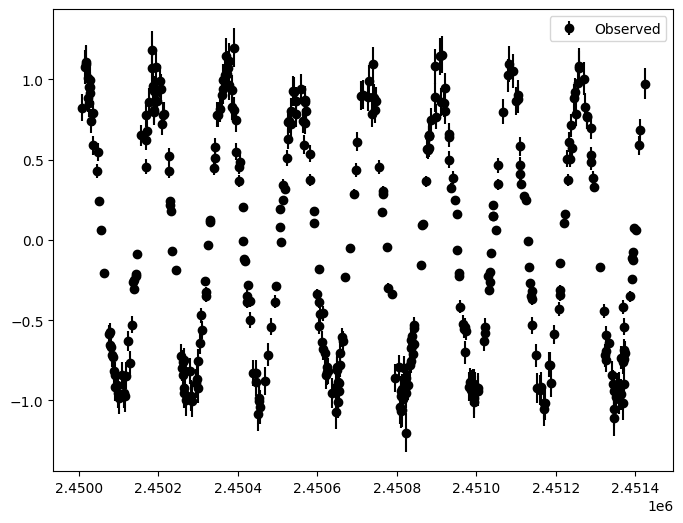

In [29]:
_ = lc1d_manual.plot()

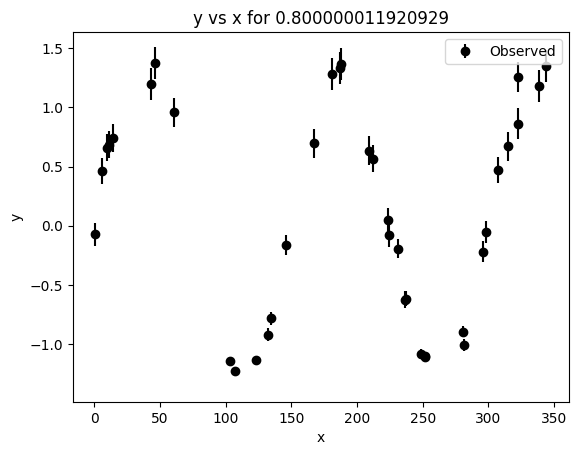

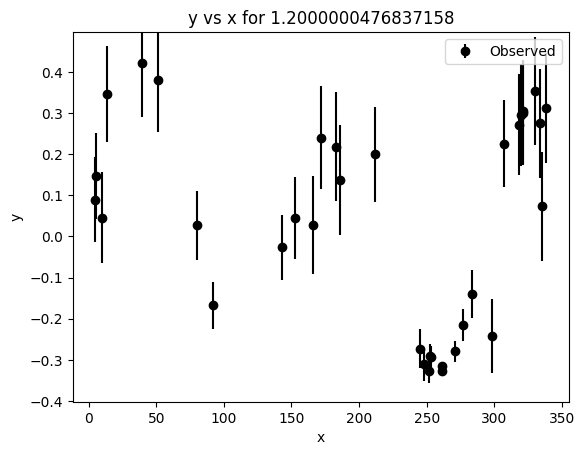

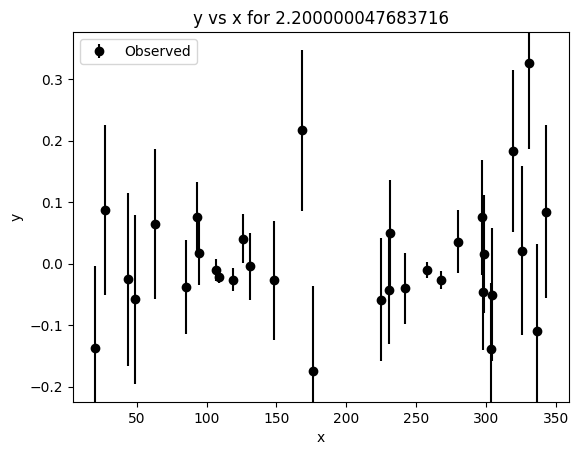

In [30]:
_ = lc2d_synth_1comp.plot()

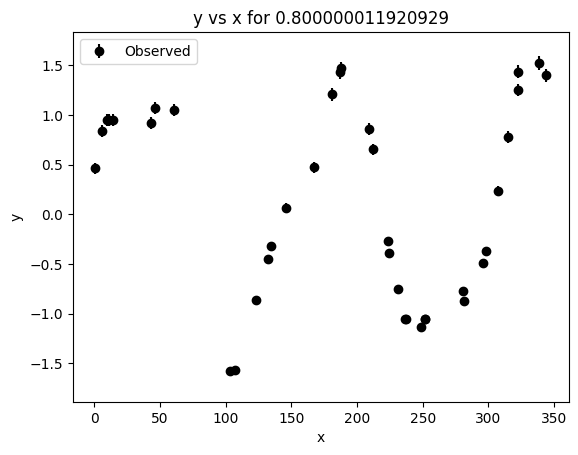

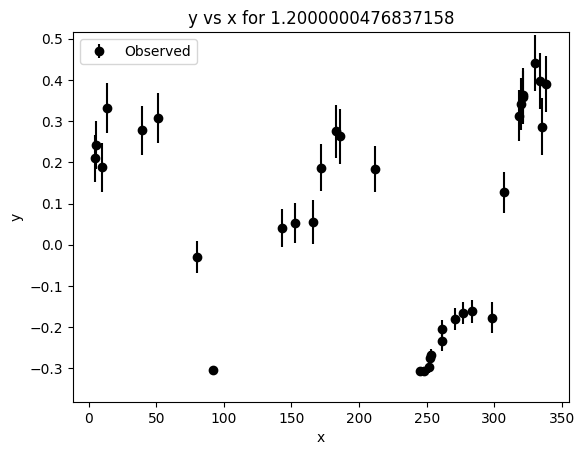

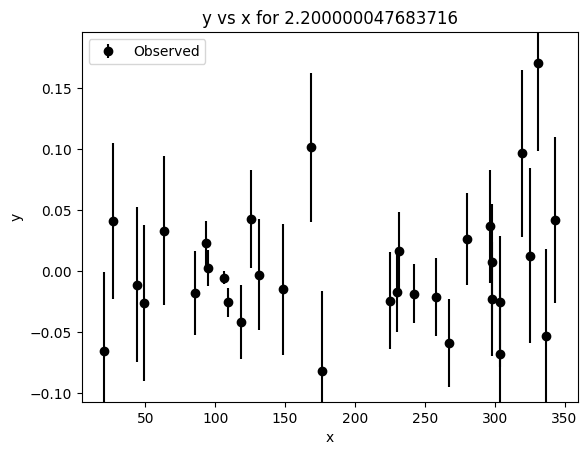

In [31]:
_ = lc2d_synth_2comp.plot()

### Input/output to CSV

##### We can use the `.from_csv()` and `.to_csv()` methods.

A few important details from the current code base:

- `.to_csv()` always writes the columns
  - `time`
  - `wavelength`
  - `flux`
- it also writes
  - `flux_error` if `yerr` is present
  - `band` if the `Lightcurve` has a `band` attribute
- for a **1D** light curve, the exported `wavelength` column is written as `0.0` for every row
- `.from_csv()` auto-detects standard column names and reconstructs either
  - a **1D** light curve, or
  - a **2D** light curve if a numeric wavelength column with multiple unique values is present
- if a string-valued band-ID column is present in the CSV, `.from_csv()` can populate the `band` attribute automatically

Because of this, a useful sanity check is a **round-trip** test:

```python
lc.to_csv(...)
lc2 = Lightcurve.from_csv(...)
```

In [32]:
# Simple CSV round-trip for a 1D light curve

outpath="lc1d_manual.csv"
_ = lc1d_manual.to_csv(outpath)
lc_read = Lightcurve.from_csv(outpath)

print("Written file:", outpath)
print("Original ndim:", lc1d_manual.ndim)
print("Read-back ndim:", lc_read.ndim)

print("\nArray comparisons:")
print("xdata equal ->", np.allclose(np.asarray(lc1d_manual.xdata), np.asarray(lc_read.xdata)))
print("ydata equal ->", np.allclose(np.asarray(lc1d_manual.ydata), np.asarray(lc_read.ydata)))

if lc1d_manual.yerr is not None and lc_read.yerr is not None:
    print("yerr equal  ->", np.allclose(np.asarray(lc1d_manual.yerr), np.asarray(lc_read.yerr)))
else:
    print("yerr equal  ->", lc1d_manual.yerr is None and lc_read.yerr is None)

print("\nBand information:")
print("original band ->", lc1d_manual.band)
print("read-back band ->", lc_read.band)

Written file: lc1d_manual.csv
Original ndim: 1
Read-back ndim: 1

Array comparisons:
xdata equal -> True
ydata equal -> True
yerr equal  -> True

Band information:
original band -> None
read-back band -> None


In [33]:
# CSV round-trip for a 2D light curve with band labels

outpath_2d = "lc2d_synth_1comp.csv"
_ = lc2d_synth_1comp.to_csv(outpath_2d)
lc2d_read = Lightcurve.from_csv(outpath_2d)

print("Written file:", outpath_2d)
print("Original ndim:", lc2d_synth_1comp.ndim)
print("Read-back ndim:", lc2d_read.ndim)

print("\nShape checks:")
print("xdata shape:", np.asarray(lc2d_synth_1comp.xdata).shape, "->", np.asarray(lc2d_read.xdata).shape)
print("ydata shape:", np.asarray(lc2d_synth_1comp.ydata).shape, "->", np.asarray(lc2d_read.ydata).shape)

print("\nArray comparisons:")
print("xdata equal ->", np.allclose(np.asarray(lc2d_synth_1comp.xdata), np.asarray(lc2d_read.xdata)))
print("ydata equal ->", np.allclose(np.asarray(lc2d_synth_1comp.ydata), np.asarray(lc2d_read.ydata)))

if lc2d_synth_1comp.yerr is not None and lc2d_read.yerr is not None:
    print("yerr equal  ->", np.allclose(np.asarray(lc2d_synth_1comp.yerr), np.asarray(lc2d_read.yerr)))
else:
    print("yerr equal  ->", lc2d_synth_1comp.yerr is None and lc2d_read.yerr is None)

print("\nBand comparisons:")
print("original unique bands ->", np.unique(lc2d_synth_1comp.band) if lc2d_synth_1comp.band is not None else None)
print("read-back unique bands ->", np.unique(lc2d_read.band) if lc2d_read.band is not None else None)

if lc2d_synth_1comp.band is not None and lc2d_read.band is not None:
    print("band array equal ->", np.array_equal(np.asarray(lc2d_synth_1comp.band), np.asarray(lc2d_read.band)))
else:
    print("band array equal ->", lc2d_synth_1comp.band is None and lc2d_read.band is None)

Written file: lc2d_synth_1comp.csv
Original ndim: 2
Read-back ndim: 2

Shape checks:
xdata shape: (106, 2) -> (106, 2)
ydata shape: (106,) -> (106,)

Array comparisons:
xdata equal -> True
ydata equal -> True
yerr equal  -> True

Band comparisons:
original unique bands -> None
read-back unique bands -> None
band array equal -> True


### The `band` attribute; selecting, dropping, merging, and concatenating light curves.

These operations are easy to misuse if one assumes Python-list-like in-place behavior.

In the current code base:

- `select_bands()` returns a **new** `Lightcurve`
- `drop_bands()` returns a **new** `Lightcurve`
- `merge()` returns a **new** `Lightcurve`
- `Lightcurve.concat()` returns a **new** `Lightcurve`
- `Lightcurve.from_csv()` creates a **new** `Lightcurve`
- `to_csv()` writes a file to disk and returns the output path; it does **not** modify the object

So none of the light-curve manipulation methods demonstrated in this section operate in place.

This matters because code such as

```python
lc.select_bands(['band 2'])
```
does **not** alter `lc` unless the returned object is assigned:
```python
lc2 = lc.select_bands(['band 2'])
```

The same logic applies to `drop_bands()`, `merge()`, and `concat()`.

##### Populating the `band` attribute
##### `band` can be populated as follows if it doesn't already exist

In [34]:
bands = ['band 1', 'band 2', 'band 3']
u, c = np.unique(lc2d_synth_1comp.xdata[:, 1], return_counts=True)
ks = np.argsort(u)
band_value = np.repeat('band 1', lc2d_synth_1comp.xdata[:, 1].shape)
for uu in u[ks]:
  idx = np.where(lc2d_synth_1comp.xdata[:, 1] == uu)[0]
  band_value[idx] = bands[ks[np.where(u == uu)[0][0]]]

lc2d_synth_1comp.band = band_value

###### We can now write the updated Lightcurve object to a file for posterity

In [35]:
_ = lc2d_synth_1comp.to_csv("lightcurve_band123.csv")

##### `select_bands`

##### Once a `band` attribute is available, we can select a subset of the light curve into a new `Lightcurve` object.

A few important details from the current implementation:

- selection is based **only** on the `band` attribute
- the wavelength values in `xdata[:, 1]` are **not** used for selection
- the input must be a sequence (`list`, `tuple`, or `numpy.ndarray`) of string labels
- a bare string such as `lc.select_bands("band 2")` is **not** allowed
- numeric selectors such as `1`, `1.0`, etc. are rejected
- if none of the requested labels are present, a `ValueError` is raised
- the returned object preserves the original row ordering
- this method returns a **new** `Lightcurve`; it does **not** modify the original in place

Also note that repeated labels in `band` are expected: for a 2D light curve, the same band label appears in many rows, one per observation in that band.

In [36]:
lc23 = lc2d_synth_1comp.select_bands(['band 2', 'band 3'])

print("Original object unchanged?")
print("  lc23 is lc2d_synth_1comp ->", lc23 is lc2d_synth_1comp)

print(f"\nNo. of observations in lc2d_synth_1comp: {lc2d_synth_1comp.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc2d_synth_1comp.band, return_counts=True)
for uu, cc in zip(u, c):
    print(uu, cc)

print(f"\nNo. of observations in lc23: {lc23.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc23.band, return_counts=True)
for uu, cc in zip(u, c):
    print(uu, cc)

print("\nFirst few selected band labels (row ordering preserved):")
print(lc23.band[:10])

Original object unchanged?
  lc23 is lc2d_synth_1comp -> False

No. of observations in lc2d_synth_1comp: torch.Size([106])
Breakdown by band:
band 1 38
band 2 35
band 3 33

No. of observations in lc23: torch.Size([68])
Breakdown by band:
band 2 35
band 3 33

First few selected band labels (row ordering preserved):
['band 2' 'band 2' 'band 2' 'band 2' 'band 2' 'band 2' 'band 2' 'band 2'
 'band 2' 'band 2']


In [37]:
# Edge cases for select_bands()

cases = [
    ("bare string", lambda: lc2d_synth_1comp.select_bands("band 2")),
    ("numeric selector", lambda: lc2d_synth_1comp.select_bands([2])),
    ("float selector", lambda: lc2d_synth_1comp.select_bands([2.0])),
    ("missing band", lambda: lc2d_synth_1comp.select_bands(["band 999"])),
]

for label, func in cases:
    try:
        _ = func()
        print(f"{label}: unexpectedly succeeded")
    except Exception as e:
        print(f"{label}: {type(e).__name__}: {e}")
        print("")

bare string: TypeError: 'bands' must be a sequence of band labels (list, tuple, or numpy.ndarray), not a bare string. To select a single band wrap it in a list: select_bands(['band 2'])

numeric selector: TypeError: Numeric selectors are not supported by select_bands; got 'int' (2). Use a string band label instead.

float selector: TypeError: Numeric selectors are not supported by select_bands; got 'float' (2.0). Use a string band label instead.

missing band: ValueError: None of the requested band labels ['band 999'] were found in this Lightcurve's 'band' attribute.



##### `drop_bands`

##### We can also create a new `Lightcurve` object by removing one or more bands from the original.

The validation rules are similar to those for `select_bands`:

- removal is based **only** on the `band` attribute
- the input must be a sequence of strings
- a bare string is rejected
- if a requested label is not present, this is a **no-op** for that label
- if all rows would be removed, a `ValueError` is raised
- the method returns a **new** `Lightcurve`; it does **not** modify the original in place

So `drop_bands()` differs from `select_bands()` in one important way:

- `select_bands()` raises an error if none of the requested labels exist
- `drop_bands()` simply returns a copy of the original object if the requested labels do not occur

In [38]:
lc1 = lc2d_synth_1comp.drop_bands(['band 2', 'band 3'])

print("Original object unchanged?")
print("  lc1 is lc2d_synth_1comp ->", lc1 is lc2d_synth_1comp)

print(f"\nNo. of observations in lc1: {lc1.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc1.band, return_counts=True)
for uu, cc in zip(u, c):
    print(uu, cc)

Original object unchanged?
  lc1 is lc2d_synth_1comp -> False

No. of observations in lc1: torch.Size([38])
Breakdown by band:
band 1 38


In [39]:
# Edge cases for drop_bands()

# 1. Dropping a non-existent band: no-op copy
lc_noop = lc2d_synth_1comp.drop_bands(['band 999'])
print("Dropping a non-existent band leaves the content unchanged:")
print("  same number of rows ->", len(lc_noop.ydata) == len(lc2d_synth_1comp.ydata))
print("  same unique bands    ->", np.array_equal(np.unique(lc_noop.band), np.unique(lc2d_synth_1comp.band)))

# 2. Invalid selectors
cases = [
    ("bare string", lambda: lc2d_synth_1comp.drop_bands("band 2")),
    ("numeric selector", lambda: lc2d_synth_1comp.drop_bands([2])),
]

for label, func in cases:
    try:
        _ = func()
        print(f"{label}: unexpectedly succeeded")
    except Exception as e:
        print(f"{label}: {type(e).__name__}: {e}")
        print("")

# 3. Removing all available bands
try:
    all_bands = list(np.unique(lc2d_synth_1comp.band))
    _ = lc2d_synth_1comp.drop_bands(all_bands)
    print("remove all bands: unexpectedly succeeded")
except Exception as e:
    print(f"remove all bands: {type(e).__name__}: {e}")
    print("")

Dropping a non-existent band leaves the content unchanged:
  same number of rows -> True
  same unique bands    -> True
bare string: TypeError: 'bands' must be a sequence of labels (list, tuple, or numpy.ndarray), not a bare string. To drop a single band wrap it in a list: drop_bands(['band 2'])

numeric selector: TypeError: Each element of 'bands' must be a string; got 'int'.

remove all bands: ValueError: All rows were removed by drop_bands; no data remains.



##### `merge`

##### Data from one `Lightcurve` object can be merged into another by appending one or more **new bands**.

Important behavior in the current code base:

- `merge()` requires `self` to be a **2D** `Lightcurve`
- `other` must be:
  - another `Lightcurve`, or
  - the path to a CSV file containing a light curve
- `other` must represent **new constituent band(s)**:
  - duplicate **band labels** are conflicts
  - duplicate **wavelengths** are also conflicts
- by default, conflicts raise a `ValueError`
- with `on_conflict="skip"`, conflicting constituent bands are skipped with a `UserWarning`
- `merge()` returns a **new** 2D `Lightcurve`; it does **not** modify the original in place

Also note:

- if `other` is **1D**, you must supply `wavelength=...`
- if a 1D `other` has no `band` attribute, you must also supply `band=...`
- if `other` is already 2D, you must **not** supply `wavelength`

In [40]:
lc123 = lc23.merge(lc1)

print("merge returns a new object:")
print("  lc123 is lc23 ->", lc123 is lc23)
print("  lc123 is lc1  ->", lc123 is lc1)

print(f"\nNo. of observations in lc123: {lc123.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc123.band, return_counts=True)
for uu, cc in zip(u, c):
    print(uu, cc)

merge returns a new object:
  lc123 is lc23 -> False
  lc123 is lc1  -> False

No. of observations in lc123: torch.Size([106])
Breakdown by band:
band 1 38
band 2 35
band 3 33


###### `merge()` also accepts a CSV file name as its argument and reads in the light curve before merging.

This is convenient, but the same conflict rules still apply:

- duplicate band labels are not allowed
- duplicate wavelengths are not allowed
- `on_conflict="raise"` is the default

In [41]:
lc23.to_csv('lightcurve_band23.csv')
lc123 = lc1.merge("lightcurve_band23.csv")
print(f"No. of observations in lc123: {lc123.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc123.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

No. of observations in lc123: torch.Size([106])
Breakdown by band:
band 1 38
band 2 35
band 3 33


###### If the CSV file contains a **1D** light curve, `merge()` needs enough information to promote it to 2D.

That means:

- `wavelength=...` is required
- if the 1D input has no `band` attribute, you must also pass `band=...`

Without this information, the 1D input cannot be turned into a constituent band of a 2D light curve.

In [42]:
lc1.to_csv("lightcurve_band1.csv")
lc123 = lc23.merge("lightcurve_band1.csv", wavelength=0.8)
print(f"No. of observations in lc123: {lc123.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc123.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

No. of observations in lc123: torch.Size([106])
Breakdown by band:
b 38
band 2 35
band 3 33


In [43]:
# Failure cases for merge()

# 1. Attempt to merge a duplicate band / wavelength
try:
    _ = lc23.merge(lc23)
    print("duplicate merge: unexpectedly succeeded")
except Exception as e:
    print("duplicate merge:", type(e).__name__, e)

# 2. The same duplicate merge, but skipping conflicts
try:
    lc_skip = lc23.merge(lc23, on_conflict="skip")
    print("\nmerge(..., on_conflict='skip') succeeded")
    print("Unique bands in result:", np.unique(lc_skip.band))
except Exception as e:
    print("skip-conflict merge failed:", type(e).__name__, e)
    print("")

# 3. Supplying wavelength for an already-2D input is not allowed
try:
    _ = lc23.merge(lc1, wavelength=0.8)
    print("2D merge with wavelength: unexpectedly succeeded")
except Exception as e:
    print("\n2D merge with wavelength:", type(e).__name__, e)
    print("")

duplicate merge: ValueError Conflict detected: band np.str_('band 2') already exists in 'self'. Use on_conflict='skip' to skip conflicting bands.

merge(..., on_conflict='skip') succeeded
Unique bands in result: ['band 2' 'band 3']

2D merge with wavelength: ValueError 'wavelength' must not be provided when 'other' is already a 2-D lightcurve.



/tmp/ipykernel_2728/2310318970.py:12: UserWarning: Skipping band np.str_('band 2') from 'other': band np.str_('band 2') already exists in 'self'.
  lc_skip = lc23.merge(lc23, on_conflict="skip")
/tmp/ipykernel_2728/2310318970.py:12: UserWarning: Skipping band np.str_('band 3') from 'other': band np.str_('band 3') already exists in 'self'.
  lc_skip = lc23.merge(lc23, on_conflict="skip")


##### `concat`

##### `Lightcurve.concat()` combines multiple light curves into a **new 2D Lightcurve**.

Compared with `merge()`:

- `merge()` is an **instance method** operating on one base object plus one additional input
- `concat()` is a **class method** that combines a list of inputs

Like `merge()`, `concat()` enforces uniqueness of constituent bands:

- no duplicate **band labels**
- no duplicate **wavelengths**

It also supports a mixture of inputs:

- `Lightcurve` objects
- CSV file names

For a **1D** input, promotion to 2D is only possible if the object already carries enough wavelength metadata internally. Otherwise `concat()` raises an error.

In [44]:
lc123 = Lightcurve.concat([lc1, lc23])
lc123 = Lightcurve.concat(["lightcurve_band23.csv", lc1])

###### `concat()` checks for duplicate constituent bands across all inputs.

A conflict is triggered if either of the following appears in more than one input:

- the same **band label**
- the same **wavelength**

By default this raises a `ValueError`.

In [45]:
lc_1 = lc1
try:
  lc123 = Lightcurve.concat([lc1, lc23, lc_1])
except Exception as e:
  print(type(e).__name__, e)

ValueError Conflict detected: band np.str_('band 1') appears in more than one input. Use on_conflict='skip' to skip conflicting bands.


###### `on_conflict="raise"` is the default so that duplicate constituent bands are not ignored silently.

If `on_conflict="skip"` is used, conflicting bands are skipped and a `UserWarning` is emitted instead.

One more important difference from `merge()`:

- `concat()` cannot always promote a 1D light curve automatically
- the 1D object must already carry a scalar wavelength internally (for example in `wavelength`, `wave`, or `lambda_`)
- otherwise `concat()` raises a `ValueError`

In [46]:
lc_1 = lc1
lc123 = Lightcurve.concat([lc1, lc23, lc_1], on_conflict="skip")

/tmp/ipykernel_2728/2348824447.py:2: UserWarning: Skipping band np.str_('band 1'): band np.str_('band 1') appears in more than one input.
  lc123 = Lightcurve.concat([lc1, lc23, lc_1], on_conflict="skip")


In [47]:
# Additional concat failure mode:
# a 1D input cannot be promoted to 2D unless it carries scalar wavelength metadata

lc1d_no_wavelength = Lightcurve(
    lc1d_manual.xdata,
    lc1d_manual.ydata,
    yerr=lc1d_manual.yerr,
    band=lc1d_manual.band,
)

# Remove possible scalar wavelength metadata if present
for attr in ("wavelength", "wave", "lambda_"):
    if hasattr(lc1d_no_wavelength, attr):
        try:
            setattr(lc1d_no_wavelength, attr, None)
        except Exception:
            pass

try:
    _ = Lightcurve.concat([lc23, lc1d_no_wavelength])
    print("concat with 1D input lacking wavelength metadata: unexpectedly succeeded")
except Exception as e:
    print("concat with 1D input lacking wavelength metadata:", type(e).__name__, e)

concat with 1D input lacking wavelength metadata: ValueError All inputs must have band information if any one of them does. Found a mix of inputs with and without 'band'.


##### Copy vs in-place semantics for `select_bands`, `drop_bands`, `merge`, and `concat`

In [48]:
# Demonstrate copy vs in-place semantics for the main manipulation methods

print("Original unique bands in lc2d_synth_1comp:")
print(np.unique(lc2d_synth_1comp.band))

# 1. select_bands without assignment: original object is unchanged
_ = lc2d_synth_1comp.select_bands(['band 2'])
print("\nAfter calling select_bands(...) without assignment:")
print(np.unique(lc2d_synth_1comp.band))

# 2. drop_bands without assignment: original object is unchanged
_ = lc2d_synth_1comp.drop_bands(['band 2'])
print("\nAfter calling drop_bands(...) without assignment:")
print(np.unique(lc2d_synth_1comp.band))

# 3. with assignment, a new object is produced
lc_selected = lc2d_synth_1comp.select_bands(['band 2'])
lc_dropped = lc2d_synth_1comp.drop_bands(['band 2'])

print("\nBands in lc_selected:")
print(np.unique(lc_selected.band))

print("\nBands in lc_dropped:")
print(np.unique(lc_dropped.band))

print("\nObject identity checks:")
print("lc_selected is lc2d_synth_1comp ->", lc_selected is lc2d_synth_1comp)
print("lc_dropped  is lc2d_synth_1comp ->", lc_dropped is lc2d_synth_1comp)

# 4. merge also returns a new object
lc_merged = lc_selected.merge(lc_dropped)
print("\nlc_merged is lc_selected ->", lc_merged is lc_selected)
print("lc_merged is lc_dropped  ->", lc_merged is lc_dropped)

# 5. concat returns a new object
lc_concat = Lightcurve.concat([lc_selected, lc_dropped])
print("\nlc_concat is lc_selected ->", lc_concat is lc_selected)
print("lc_concat is lc_dropped  ->", lc_concat is lc_dropped)

Original unique bands in lc2d_synth_1comp:
['band 1' 'band 2' 'band 3']

After calling select_bands(...) without assignment:
['band 1' 'band 2' 'band 3']

After calling drop_bands(...) without assignment:
['band 1' 'band 2' 'band 3']

Bands in lc_selected:
['band 2']

Bands in lc_dropped:
['band 1' 'band 3']

Object identity checks:
lc_selected is lc2d_synth_1comp -> False
lc_dropped  is lc2d_synth_1comp -> False

lc_merged is lc_selected -> False
lc_merged is lc_dropped  -> False

lc_concat is lc_selected -> False
lc_concat is lc_dropped  -> False


### Subsampling light curves

Large light curves can become expensive to work with, especially before downstream methods such as `fit_LS()` and `fit()`.

In the current code base, there are **two separate controls**:

- `max_samples`
- `max_samples_per_band`

These do **not** behave the same way for 1D and 2D light curves.

#### 1D light curves
If the total number of points exceeds `max_samples`, the object is automatically subsampled and the reduced data are stored in the resulting `Lightcurve`.

#### 2D light curves
For multiband data, `max_samples_per_band` is the parameter that actually triggers subsampling. Each band is checked independently, and only bands above the threshold are reduced.

By contrast, for 2D light curves, `max_samples` is mainly a **compute-budget advisory**: if the total number of rows is very large, a warning is issued to indicate that later calculations may become slow.

This matters because a 2D `Lightcurve` stores one row per observation, so memory use and execution time both scale with the total number of rows.

##### We will demonstrate subsampling on a light curve with a large number of points. We will also demonstrate how subsampling works with a 2D `Lightcurve` object.

/usr/local/lib/python3.12/dist-packages/pgmuvi/synthetic.py:907: UserWarning: Lightcurve has 9253 points, which exceeds max_samples=1000. Execution may be slow. Consider setting max_samples_per_band to reduce the total size of the lightcurve.
  return Lightcurve(x, y, yerr=yerr)


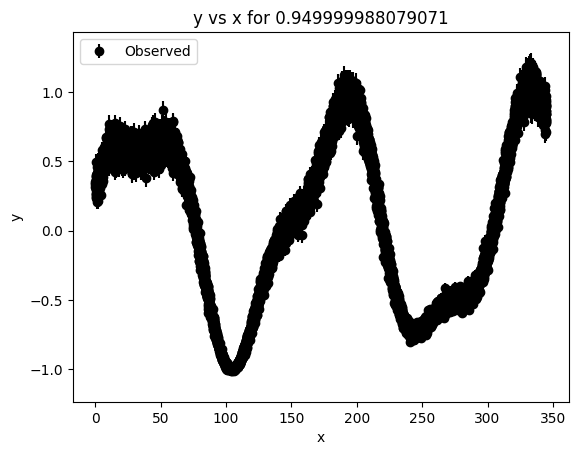

[<Figure size 640x480 with 1 Axes>]

In [49]:
# Generate a light curve at a new wavelength with a large number of data points

n_per_band = (5000, 10000) # number of data points per light curve limited to this range

# generate a set of light curves with two period components and a phase lag
# dataset_type="make_multi_sinusoid_chromatic_2d", # series of synthetic light curves with two period components and a phase lag
MULTI_DATASET_CONFIG = dict(
    components=[
        {"period": 150.0, "amplitude_fraction": 1.0, "phase": 0.0},
        {"period": 66.0, "amplitude_fraction": 0.3, "phase": np.pi / 2 * 0.85},
    ],
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.95],
    amplitude_law="extinction",
    noise_level=0.05,
    seed=SEED,
)

lc1_5 = synthetic.make_multi_sinusoid_chromatic_2d(**MULTI_DATASET_CONFIG)
lc1_5.band = np.repeat('band 1.5', lc1_5.xdata[:, 0].shape)
lc1_5.plot()

###### Note the `UserWarning` that already suggests adjusting two arguments: `max_samples` and `max_samples_per_band`. These are explained below.

Let us first merge this new light curve into the existing data:

In [50]:
lc123 = Lightcurve.from_csv("lightcurve_band123.csv")

lc1234 = lc123.merge(lc1_5)
print(lc1234.xdata.shape)
print(np.unique(lc1234.band))

torch.Size([9359, 2])
['band 1' 'band 1.5' 'band 2' 'band 3']


/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:10574: UserWarning: Lightcurve has 9359 points, which exceeds max_samples=1000. Execution may be slow. Consider setting max_samples_per_band to reduce the total size of the lightcurve.
  return type(self)(


##### PGMUVI can generate a report summarising the sampling quality of the data. Based on various criteria (see `preprocess/quality.py`), the code suggests whether a band should be included when executing `fit_LS` or `fit`.

There are **two related but distinct interfaces** here:

1. `.compute_sampling_metrics()` / `.compute_sampling_metrics_per_band()`  
   These return numerical diagnostics such as:
   - number of points
   - baseline
   - median and mean cadence
   - Nyquist period
   - Nyquist frequency
   - longest detectable period
   - maximum gap fraction
   - duty cycle

2. `.assess_sampling_quality()` / `.assess_sampling_quality_per_band()`  
   These apply threshold-based quality gates and return a recommendation about whether the light curve is suitable for later analysis.

The second interface is what is used internally when a `Lightcurve` is instantiated with `check_sampling=True`.

For 2D light curves, `check_sampling=True` checks each wavelength independently. Bands that fail are removed automatically, and a `ValueError` is raised only if **no** bands pass.

In [51]:
# Numerical sampling diagnostics per band

sampling_metrics = lc1234.compute_sampling_metrics_per_band()

print("Summary:")
print(sampling_metrics["summary"])

print("\nPer-band metrics:")
for wl, metrics in sampling_metrics.items():
    if wl == "summary":
        continue
    print(f"\nWavelength = {wl}")
    print(f"  n_points                  = {metrics['n_points']}")
    print(f"  baseline                  = {metrics['baseline']:.3f}")
    print(f"  median_cadence            = {metrics['median_cadence']:.3f}")
    print(f"  mean_cadence              = {metrics['mean_cadence']:.3f}")
    print(f"  nyquist_period            = {metrics['nyquist_period']:.3f}")
    print(f"  nyquist_frequency         = {metrics['nyquist_frequency']:.6f}")
    print(f"  longest_detectable_period = {metrics['longest_detectable_period']:.3f}")
    print(f"  max_gap_fraction          = {metrics['max_gap_fraction']:.3f}")
    print(f"  duty_cycle                = {metrics['duty_cycle']:.3f}")

print("\nQuality-gate assessment:")
sampling_quality = lc1234.assess_sampling_quality_per_band(verbose=False)
print(sampling_quality["summary"])

Summary:
{'n_bands': 4, 'min_points_across_bands': 33, 'max_gap_fraction_worst_band': 0.15367545487568915, 'median_nyquist_period': 12.191802978515625}

Per-band metrics:

Wavelength = 0.800000011920929
  n_points                  = 38
  baseline                  = 343.093
  median_cadence            = 5.649
  mean_cadence              = 9.273
  nyquist_period            = 11.298
  nyquist_frequency         = 0.088508
  longest_detectable_period = 171.546
  max_gap_fraction          = 0.125
  duty_cycle                = 0.626

Wavelength = 0.949999988079071
  n_points                  = 9253
  baseline                  = 344.962
  median_cadence            = 0.026
  mean_cadence              = 0.037
  nyquist_period            = 0.053
  nyquist_frequency         = 18.933858
  longest_detectable_period = 172.481
  max_gap_fraction          = 0.001
  duty_cycle                = 0.708

Wavelength = 1.2000000476837158
  n_points                  = 35
  baseline                  = 333.439
 

In [52]:
# Demonstrate what check_sampling=True does during Lightcurve construction.
#
# For a 2D light curve, each band is checked independently.
# Bands that fail the sampling criteria are removed automatically.

lc_checked = Lightcurve(
    lc1234.xdata,
    lc1234.ydata,
    yerr=lc1234.yerr,
    band=lc1234.band,
    check_sampling=True,
)

print("Original wavelengths:")
print(np.unique(lc1234.xdata[:, 1]))

print("\nRetained wavelengths after check_sampling=True:")
print(np.unique(lc_checked.xdata[:, 1]))

print("\nOriginal observation count:", len(lc1234.ydata))
print("Retained observation count:", len(lc_checked.ydata))

Original wavelengths:
[0.8  0.95 1.2  2.2 ]

Retained wavelengths after check_sampling=True:
[0.8  0.95]

Original observation count: 9359
Retained observation count: 9291


/tmp/ipykernel_2728/4055812079.py:6: UserWarning: Skipping band λ=1.2000000476837158 due to poor temporal sampling: Poor SNR: median=2.4 < 3.0, fraction>=3.0=29% < 50%
  lc_checked = Lightcurve(
/tmp/ipykernel_2728/4055812079.py:6: UserWarning: Skipping band λ=2.200000047683716 due to poor temporal sampling: Poor SNR: median=0.6 < 3.0, fraction>=3.0=0% < 50%
  lc_checked = Lightcurve(
/tmp/ipykernel_2728/4055812079.py:6: UserWarning: Retaining 2/4 wavelength bands after sampling-quality filtering (skipping λ = [1.2, 2.2]).
  lc_checked = Lightcurve(
/tmp/ipykernel_2728/4055812079.py:6: UserWarning: Lightcurve has 9291 points, which exceeds max_samples=1000. Execution may be slow. Consider setting max_samples_per_band to reduce the total size of the lightcurve.
  lc_checked = Lightcurve(


##### A single light curve can be subsampled as follows:

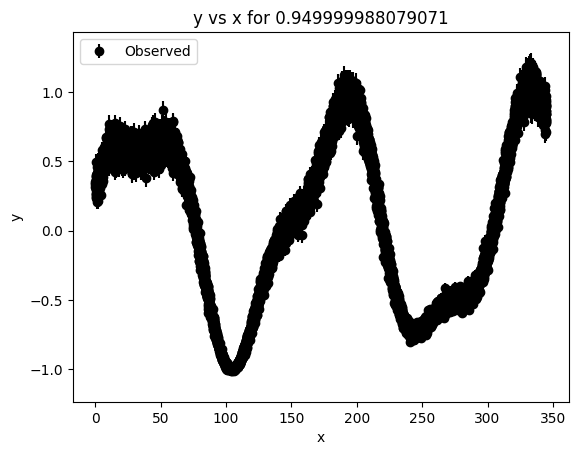

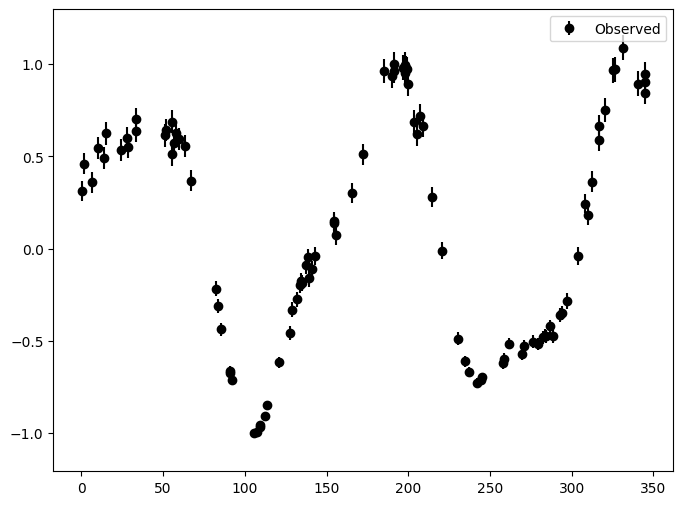

In [53]:
idx = subsample_lightcurve(lc1_5.xdata[:, 0], max_samples=100)
lc_sub = Lightcurve(xdata=lc1_5.xdata[idx, 0], ydata=lc1_5.ydata[idx],
                    yerr=lc1_5.yerr[idx], band=[lc1_5.band[idx[0]]])
_ = lc1_5.plot()
_ = lc_sub.plot()

##### The `max_samples_per_band` argument determines which bands in a 2D `Lightcurve` object need to be subsampled.

Bands with fewer than `max_samples_per_band` points are left unchanged.

However, there is an important practical distinction:

- `max_samples_per_band` controls **automatic row reduction**
- `max_samples` controls the **warning threshold** for the total number of rows in a 2D light curve

So for large 2D datasets:

- increasing `max_samples_per_band` preserves more information but may slow later analysis
- decreasing `max_samples_per_band` reduces the per-band row count and can make later methods more tractable
- setting `max_samples` to a larger value suppresses warnings, but does **not** itself reduce the size of a 2D light curve

In short: for 2D light curves, `max_samples_per_band` is the real performance knob.

In [54]:
_ = lc1234.to_csv("lightcurve_bands1234.csv")
print(f"No. of observations in lc1234: {lc1234.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc1234.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

No. of observations in lc1234: torch.Size([9359])
Breakdown by band:
band 1 38
band 1.5 9253
band 2 35
band 3 33


###### We set `max_samples` such that subsampling is only applied to the band that actually needs it:

In [55]:
lc = Lightcurve.from_csv("lightcurve_bands1234.csv", max_samples=1000,
                         max_samples_per_band=98)

/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:824: UserWarning: The following bands exceed max_samples_per_band=98 and were randomly subsampled: λ=0.949999988079071. Set max_samples_per_band=None to disable subsampling.
The subsampled 2D light curve has the following structure:
    λ=0.800000011920929: 38 points
    λ=0.949999988079071: 98 points
    λ=1.2000000476837158: 35 points
    λ=2.200000047683716: 33 points
  return cls(xdata=x, ydata=y, yerr=yerr, **kwargs)


In [56]:
# Simple size / memory sanity check before and after subsampling

def lightcurve_size_report(lc_obj, label):
    x_nbytes = np.asarray(lc_obj.xdata).nbytes
    y_nbytes = np.asarray(lc_obj.ydata).nbytes
    yerr_nbytes = 0 if lc_obj.yerr is None else np.asarray(lc_obj.yerr).nbytes
    band_nbytes = 0 if getattr(lc_obj, "band", None) is None else np.asarray(lc_obj.band).nbytes

    print(label)
    print(f"  n_rows               = {len(lc_obj.ydata)}")
    print(f"  xdata shape          = {np.asarray(lc_obj.xdata).shape}")
    print(f"  ydata shape          = {np.asarray(lc_obj.ydata).shape}")
    print(f"  approx numeric bytes = {x_nbytes + y_nbytes + yerr_nbytes}")
    print(f"  approx band bytes    = {band_nbytes}")
    print(f"  approx total bytes   = {x_nbytes + y_nbytes + yerr_nbytes + band_nbytes}")

print("Before subsampling:")
lightcurve_size_report(lc1234, "lc1234")

print("\nAfter subsampling:")
lightcurve_size_report(lc, "lc")

Before subsampling:
lc1234
  n_rows               = 9359
  xdata shape          = (9359, 2)
  ydata shape          = (9359,)
  approx numeric bytes = 149744
  approx band bytes    = 299488
  approx total bytes   = 449232

After subsampling:
lc
  n_rows               = 204
  xdata shape          = (204, 2)
  ydata shape          = (204,)
  approx numeric bytes = 3264
  approx band bytes    = 6528
  approx total bytes   = 9792


##### We can visualize the subsampled `Lightcurve` object:

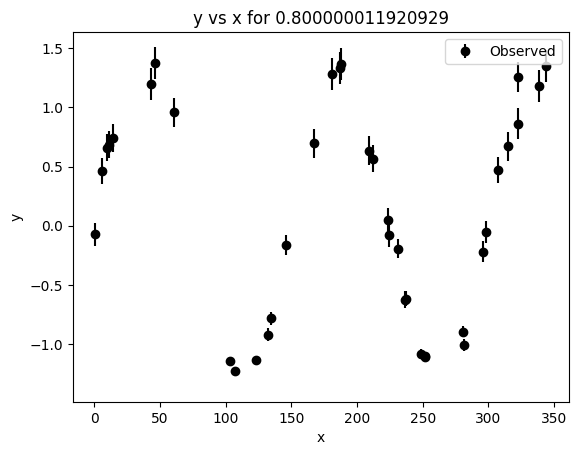

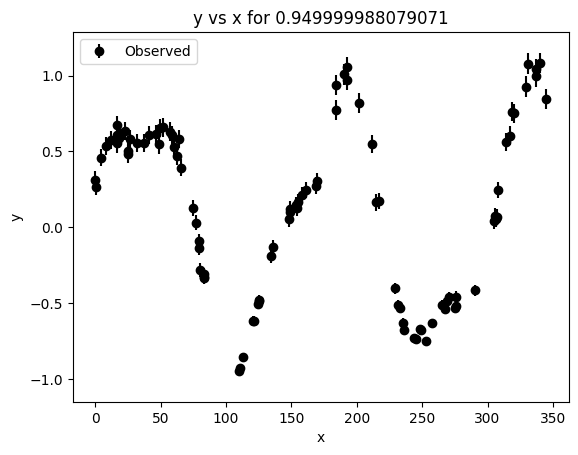

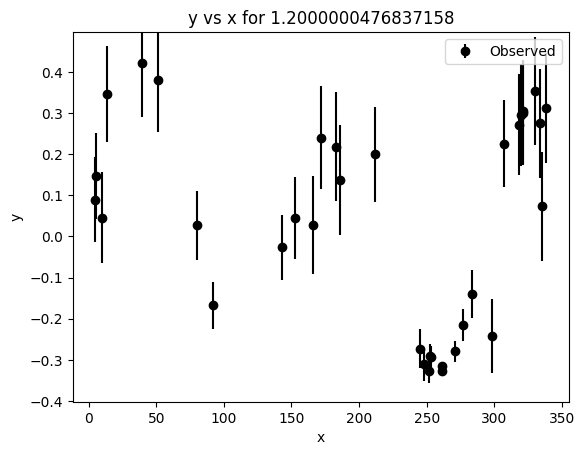

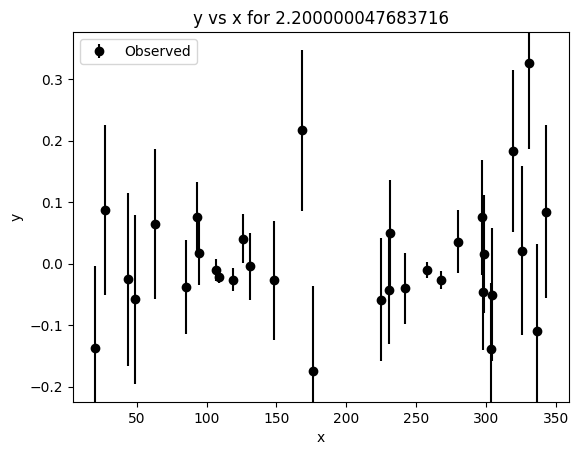

In [57]:
_ = lc.plot()

### Statistical tests for variability

##### PGMUVI can run simple statistical tests to determine whether the light curve at a given wavelength shows statistically significant variability. This is useful for deciding whether a band is worth sending to later analysis steps.

The variability logic uses three reported quantities:

1. **Weighted chi-squared test**
   - tests whether the light curve is consistent with a constant value within the reported uncertainties
   - reported via `chi2`, `dof`, and `p_value`

2. **Fractional variability**, `F_var`
   - measures whether the intrinsic variability amplitude is astrophysically meaningful after accounting for measurement errors
   - compared against the threshold `fvar_min`

3. **Stetson K**
   - reported as a **diagnostic shape/coherence metric**
   - compared against `stetson_k_min`
   - **important:** in the current code base, this does **not** veto a light curve that already passes the required chi-squared and `F_var` tests

For a 2D `Lightcurve`, the method `.check_variability_per_band()` evaluates each wavelength independently and returns:

- one diagnostics dictionary per wavelength
- a summary giving the number of variable bands and their wavelengths

Bands can then be filtered automatically with `.filter_variable_bands()`.

Below, we first inspect the full per-band diagnostics, and then demonstrate how to retain only the bands that pass the required variability gates.

In [58]:
variability_results = lc1234.check_variability_per_band()

print("Summary:")
print(variability_results["summary"])

print("\nPer-band diagnostics:")
for wl, diag in variability_results.items():
    if wl == "summary":
        continue

    print(f"\nWavelength = {wl}")
    print(f"  n_points   = {diag['n_points']}")
    print(f"  chi2       = {diag['chi2']:.3f}")
    print(f"  dof        = {diag['dof']}")
    print(f"  p_value    = {diag['p_value']:.6g}")
    print(f"  F_var      = {diag['fvar']:.6f}")
    print(f"  Stetson K  = {diag['stetson_k']:.6f}")
    print(f"  decision   = {diag['decision']}")
    print(f"  tests      = {diag['tests_passed']}")

Summary:
{'n_bands': 4, 'n_variable': 3, 'variable_wavelengths': [0.800000011920929, 0.949999988079071, 1.2000000476837158]}

Per-band diagnostics:

Wavelength = 0.800000011920929
  n_points   = 38
  chi2       = 5971.864
  dof        = 37
  p_value    = 0
  F_var      = 6.291266
  Stetson K  = 0.890367
  decision   = VARIABLE; DIAGNOSTIC: stetson_k=0.890<ref=0.950
  tests      = {'chi2_test': True, 'fvar_test': True, 'stetson_test': False, 'min_points': True}

Wavelength = 0.949999988079071
  n_points   = 9253
  chi2       = 3085250.623
  dof        = 9252
  p_value    = 0
  F_var      = 7.141045
  Stetson K  = 0.853211
  decision   = VARIABLE; DIAGNOSTIC: stetson_k=0.853<ref=0.950
  tests      = {'chi2_test': True, 'fvar_test': True, 'stetson_test': False, 'min_points': True}

Wavelength = 1.2000000476837158
  n_points   = 35
  chi2       = 450.622
  dof        = 34
  p_value    = 3.19429e-74
  F_var      = 5.267337
  Stetson K  = 0.892560
  decision   = VARIABLE; DIAGNOSTIC: stetson

In [59]:
# Keep only bands that pass the required variability gates.
# In the current implementation, Stetson K is diagnostic only:
# a band is kept if it passes the chi2 and F_var requirements.

lc_variable = lc1234.filter_variable_bands()

print("Original wavelengths:")
print(np.unique(lc1234.xdata[:, 1]))

print("\nWavelengths retained after variability filtering:")
print(np.unique(lc_variable.xdata[:, 1]))

print("\nOriginal number of observations:", len(lc1234.ydata))
print("Retained number of observations:", len(lc_variable.ydata))

Original wavelengths:
[0.8  0.95 1.2  2.2 ]

Wavelengths retained after variability filtering:
[0.8  0.95 1.2 ]

Original number of observations: 9359
Retained number of observations: 9326


/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:5111: UserWarning: Lightcurve has 9326 points, which exceeds max_samples=1000. Execution may be slow. Consider setting max_samples_per_band to reduce the total size of the lightcurve.
  return Lightcurve(new_x, new_y, yerr=new_yerr)
